In [1]:
!date

Wed Sep 16 10:18:24 PDT 2026


In [2]:
import sys
import numpy as np
import pandas as pd
import pysam

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
sys.path.insert(0, f'{projdir}/scripts/harmonize_hg38/pilot')
import chainmap

modbed_dir = f'{projdir}/data/modbed'
chain_dir = f'{projdir}/data/chains'

In [3]:
### real first-pass PMD check, not the earlier DRAFT skeleton -- literature (2026-09-16 PMD-
### feasibility fork) confirms EBV-transformed LCLs (this cohort's cell type) reliably produce
### PMDs (Frontiers in Genetics 10.3389/fgene.2017.00076). Full-cohort global methylation
### (QC04) found mean 0.647 but a real low tail to 0.521 -- picked 3 donors spanning that range
### to test whether the low-tail donor actually shows more/larger domain-scale hypomethylation,
### not just a lower flat average.
samples_meth = {'NA19338': 0.523, 'HG01981': 0.648, 'HG04187': 0.723}  # low, median, high
WINDOW = 20000  # 20kb bins; literature PMDs span 10kb-several Mb, coarse enough to see domains
CHROM = 'chr20'  # one mid-sized autosome for a feasibility pass, not genome-wide
MAXPOS = 70_000_000  # generous preallocation for a chr20-scale contig

In [4]:
def contig_for_chrom(sample, hap, chrom):
    ### each donor's hap-vs-GRCh38 chain covers chr20 with exactly one contig here (checked) --
    ### working in that contig's own assembly coordinates, no liftover needed for a
    ### within-donor domain-structure question (only cross-donor position-matching would need it)
    cm = chainmap.ChainMap(f'{chain_dir}/{sample}_hap{hap}_vs_GRCh38.chain.gz')
    recs = cm.by_q.get(chrom, [])
    contigs = sorted(set(r[2] for r in recs))
    assert len(contigs) == 1, f'{sample} hap{hap} {chrom}: expected 1 contig, got {contigs}'
    return contigs[0]


def window_profile(sample, hap, chrom):
    contig = contig_for_chrom(sample, hap, chrom)
    modbed_contig = f'{sample}#{hap}#{contig}'
    tbx = pysam.TabixFile(f'{modbed_dir}/{sample}_hap{hap}.modbed.gz')

    n_meth = np.zeros(MAXPOS, dtype=np.int32)
    n_unmeth = np.zeros(MAXPOS, dtype=np.int32)
    n_rows = 0
    max_pos_seen = 0
    for row in tbx.fetch(modbed_contig):
        f = row.split('\t')
        start = int(f[1])
        meth_field, unmeth_field = f[6], f[7]
        if meth_field not in ('', '.', '-'):
            for off in meth_field.split(','):
                if off:
                    pos = start + abs(int(off))
                    if pos < MAXPOS:
                        n_meth[pos] += 1
                        max_pos_seen = max(max_pos_seen, pos)
        if unmeth_field not in ('', '.', '-'):
            for off in unmeth_field.split(','):
                if off:
                    pos = start + abs(int(off))
                    if pos < MAXPOS:
                        n_unmeth[pos] += 1
                        max_pos_seen = max(max_pos_seen, pos)
        n_rows += 1

    n_pos = max_pos_seen + 1
    n_meth, n_unmeth = n_meth[:n_pos], n_unmeth[:n_pos]
    n_windows = n_pos // WINDOW + 1
    pad = n_windows * WINDOW - n_pos
    n_meth_p = np.pad(n_meth, (0, pad))
    n_unmeth_p = np.pad(n_unmeth, (0, pad))

    meth_w = n_meth_p.reshape(n_windows, WINDOW).sum(axis=1)
    unmeth_w = n_unmeth_p.reshape(n_windows, WINDOW).sum(axis=1)
    ### CpG-density proxy: distinct positions with >=1 call per window -- not a true CpG count
    ### (conflates coverage depth with density at this read depth), but a real per-window
    ### denominator so a window is never called 'low methylation' from near-zero data
    ncpg_w = (n_meth_p + n_unmeth_p).astype(bool).reshape(n_windows, WINDOW).sum(axis=1)

    total = meth_w + unmeth_w
    with np.errstate(invalid='ignore', divide='ignore'):
        frac = np.where(total > 0, meth_w / np.maximum(total, 1), np.nan)
    print(f'{sample} hap{hap} {chrom} ({contig}): {n_rows} reads, {n_pos} bp covered, '
          f'{n_windows} windows of {WINDOW}bp')
    return frac, ncpg_w, total

In [5]:
results = {}
for sample in samples_meth:
    for hap in (1, 2):
        results[(sample, hap)] = window_profile(sample, hap, CHROM)

NA19338 hap1 chr20 (CM087770.1): 37892 reads, 65411669 bp covered, 3271 windows of 20000bp
NA19338 hap2 chr20 (CM087786.1): 38873 reads, 67216236 bp covered, 3361 windows of 20000bp
HG01981 hap1 chr20 (CM086331.1): 48889 reads, 66294610 bp covered, 3315 windows of 20000bp
HG01981 hap2 chr20 (CM086343.1): 50038 reads, 67263451 bp covered, 3364 windows of 20000bp
HG04187 hap1 chr20 (JBJUVO010000011.1): 31724 reads, 66196597 bp covered, 3310 windows of 20000bp
HG04187 hap2 chr20 (CM099767.1): 32171 reads, 67850148 bp covered, 3393 windows of 20000bp


In [6]:
### CpG-call density sanity check -- is the density-normalization threshold below actually
### excluding anything, or is coverage dense enough everywhere that it barely matters here
for (sample, hap), (frac, ncpg, total) in results.items():
    covered = ncpg[total > 0]
    print(f'{sample} hap{hap}: median calls/window={np.median(covered):.0f}, '
          f'p10={np.percentile(covered,10):.0f}')

NA19338 hap1: median calls/window=875, p10=587
NA19338 hap2: median calls/window=869, p10=579
HG01981 hap1: median calls/window=905, p10=630
HG01981 hap2: median calls/window=891, p10=631
HG04187 hap1: median calls/window=811, p10=532
HG04187 hap2: median calls/window=792, p10=536


In [7]:
### segmentation: a window is 'low' if mean methylation < 0.70 (housekeeping/CpG-island
### promoter dips are the OTHER, unrelated kind of low-methylation region -- short and sharp,
### a single window at most -- so only runs of >=5 consecutive low windows (>=100kb) count as a
### PMD-like domain candidate here; this is a real segmentation step, not just a windowed track
MIN_CPG = 20
LOW_THRESH = 0.70
MIN_DOMAIN_WINDOWS = 5


def segment(frac, ncpg, total):
    valid = (ncpg >= MIN_CPG) & (total > 0)
    is_low = valid & (frac < LOW_THRESH)
    domains = []
    i, n = 0, len(is_low)
    while i < n:
        if is_low[i]:
            j = i
            while j < n and (is_low[j] or not valid[j]):
                j += 1
            k = j
            while k > i and not is_low[k - 1]:
                k -= 1
            if k - i >= MIN_DOMAIN_WINDOWS:
                domains.append((i, k, k - i))
            i = j
        else:
            i += 1
    return domains, valid

In [8]:
rows = []
for (sample, hap), (frac, ncpg, total) in results.items():
    domains, valid = segment(frac, ncpg, total)
    n_valid = valid.sum()
    pmd_windows = sum(k - i for i, k, _ in domains)
    pmd_mb = pmd_windows * WINDOW / 1e6
    valid_mb = n_valid * WINDOW / 1e6
    pct_pmd = 100 * pmd_mb / valid_mb if valid_mb else float('nan')
    largest_kb = max((k - i for i, k, _ in domains), default=0) * WINDOW / 1000
    mean_valid_frac = np.nanmean(np.where(valid, frac, np.nan))
    rows.append(dict(sample=sample, hap=hap, global_meth=samples_meth[sample],
                      n_domains=len(domains), pmd_mb=pmd_mb, valid_mb=valid_mb,
                      pct_chr20_in_pmd=pct_pmd, largest_domain_kb=largest_kb,
                      chr20_mean_meth=mean_valid_frac))
df = pd.DataFrame(rows)

In [9]:
df.head()

,sample,hap,global_meth,n_domains,pmd_mb,valid_mb,pct_chr20_in_pmd,largest_domain_kb,chr20_mean_meth
0,NA19338,1,0.523,81,50.66,65.42,77.438092,2960.0,0.496584
1,NA19338,2,0.523,78,53.22,67.22,79.172865,4360.0,0.487915
2,HG01981,1,0.648,92,46.00,66.30,69.381599,2760.0,0.618149
3,HG01981,2,0.648,90,46.36,67.28,68.906064,4720.0,0.617992
4,HG04187,1,0.723,80,15.68,66.14,23.707288,900.0,0.712973


In [10]:
df.shape

(6, 9)

In [11]:
### per-donor summary, both haps averaged -- the actual test of the hypothesis: does the
### low-global-methylation donor show MORE and LARGER PMD-like domains, not just a flat
### genome-wide shift with no domain structure
df.groupby('sample')[['global_meth', 'n_domains', 'pmd_mb', 'pct_chr20_in_pmd',
                       'largest_domain_kb']].mean().sort_values('global_meth')

,global_meth,n_domains,pmd_mb,pct_chr20_in_pmd,largest_domain_kb
sample,,,,,
NA19338,0.523,79.5,51.94,78.305479,3660.0
HG01981,0.648,91.0,46.18,69.143832,3740.0
HG04187,0.723,78.0,14.97,22.360570,750.0


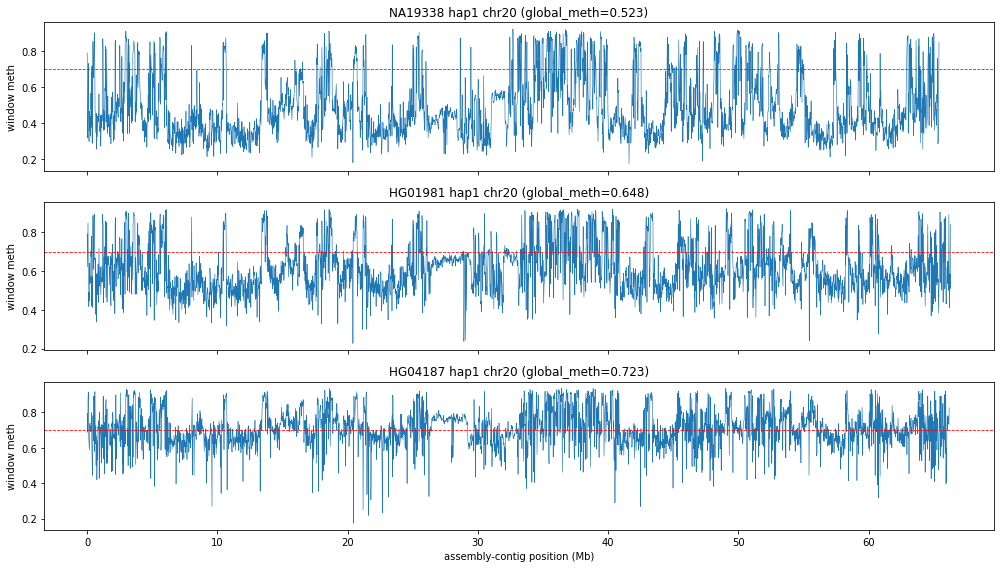

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, sample in zip(axes, samples_meth):
    frac, ncpg, total = results[(sample, 1)]
    x = np.arange(len(frac)) * WINDOW / 1e6
    ax.plot(x, frac, lw=0.6)
    ax.axhline(LOW_THRESH, color='red', ls='--', lw=0.8)
    ax.set_ylabel('window meth')
    ax.set_title(f'{sample} hap1 chr20 (global_meth={samples_meth[sample]:.3f})')
axes[-1].set_xlabel('assembly-contig position (Mb)')
plt.tight_layout()

In [13]:
outdir = f'{projdir}/results/qc/figures'
import os
os.makedirs(outdir, exist_ok=True)
fig.savefig(f'{outdir}/qc06_pmd_windowed_methylation_tracks.png', dpi=150, bbox_inches='tight')

In [14]:
outdir = f'{projdir}/results/qc/data'
df.to_csv(f'{outdir}/qc06_pmd_domains_chr20_pilot.tsv', sep='\t', index=False)

In [15]:
!date

Wed Sep 16 10:24:30 PDT 2026
